In [1]:
# 加速收敛速度 训练更多层

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [3]:
def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    if not torch.is_grad_enabled():
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)  # 特征维度上的均值和方差
        else:
            mean = X.mean(dim=(0, 2, 3), keepdim=True)  # 对 第 0、第 2、第 3 维度求平均  同时保留4维
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        X_hat = (X - mean) / torch.sqrt(var + eps)
        moving_mean = moving_mean * momentum + (1.0 - momentum) * mean
        moving_var = moving_var * momentum + (1.0 - momentum) * var
    Y = gamma * X_hat + beta
    return Y, moving_mean.data, moving_var.data

In [5]:
class BatchNorm(nn.Module):
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, x):
        if self.moving_mean.device != x.device:
            self.moving_mean = self.moving_mean.to(x.device)
            self.moving_var = self.moving_var.to(x.device)
        Y,self.moving_mean,self.moving_var = batch_norm(
            x, self.gamma, self.beta, self.moving_mean, self.moving_var,eps=1e5,momentum=0.9
        )
        return Y

In [6]:
net = nn.Sequential(
    nn.Conv2d(1,6,kernel_size=5),BatchNorm(6,num_dims=4),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),
    nn.Conv2d(6,16,kernel_size=5),BatchNorm(16,num_dims=4),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),nn.Flatten(),
    nn.Linear(16*4*4,120),BatchNorm(120, num_dims=2),nn.Sigmoid(),
    nn.Linear(120, 84),BatchNorm(84, num_dims=2),nn.Sigmoid(),
    nn.Linear(84, 10))

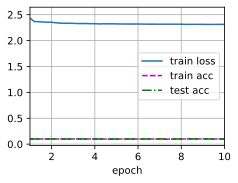

In [7]:
lr, num_epochs,batch_size = 1,10,256
train_iter, test_iter, = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch6(net,train_iter,test_iter,num_epochs,lr,d2l.try_gpu())

In [8]:
net[1].gamma.reshape((-1,)),net[1].beta.reshape((-1,))

(tensor([1., 1., 1., 1., 1., 1.], grad_fn=<ViewBackward0>),
 tensor([ 2.0013e-15,  1.7472e-15, -6.2188e-16,  1.2233e-17,  1.6083e-15,
          5.7205e-15], grad_fn=<ViewBackward0>))

In [12]:
net = nn.Sequential(
    nn.Conv2d(1,6,kernel_size=5),nn.BatchNorm2d(6),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),
    nn.Conv2d(6,16,kernel_size=5),nn.BatchNorm2d(16),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),nn.Flatten(),
    nn.Linear(16*4*4,120),nn.BatchNorm1d(120),nn.Sigmoid(),
    nn.Linear(120, 84),nn.BatchNorm1d(84),nn.Sigmoid(),
    nn.Linear(84, 10))

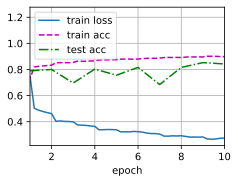

In [13]:
d2l.train_ch6(net,train_iter,test_iter,num_epochs,lr,d2l.try_gpu())

In [15]:
net[1].gamma.reshape((-1,)),net[1].beta.reshape((-1,))

AttributeError: 'BatchNorm2d' object has no attribute 'data'

In [16]:
net[1].weight.reshape((-1,)),net[1].bias.reshape((-1,))

(tensor([1.7453, 0.3314, 3.1262, 0.2691, 2.9758, 4.2582],
        grad_fn=<ViewBackward0>),
 tensor([-0.7987,  0.3302,  3.5676, -0.2881, -2.9251,  2.2907],
        grad_fn=<ViewBackward0>))